In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/should-this-loan-be-approved-or-denied/SBAnational.csv
/kaggle/input/should-this-loan-be-approved-or-denied/Should This Loan be Approved or Denied A Large Dataset with Class Assignment Guidelines.pdf


In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .appName("sba") \
        .getOrCreate()
print(spark.version)

3.5.3


In [3]:
df = spark.read.csv("/kaggle/input/should-this-loan-be-approved-or-denied/SBAnational.csv", header=True, inferSchema=True, multiLine=True, escape='"')
df.printSchema()

root
 |-- LoanNr_ChkDgt: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zip: integer (nullable = true)
 |-- Bank: string (nullable = true)
 |-- BankState: string (nullable = true)
 |-- NAICS: integer (nullable = true)
 |-- ApprovalDate: string (nullable = true)
 |-- ApprovalFY: string (nullable = true)
 |-- Term: integer (nullable = true)
 |-- NoEmp: integer (nullable = true)
 |-- NewExist: integer (nullable = true)
 |-- CreateJob: integer (nullable = true)
 |-- RetainedJob: integer (nullable = true)
 |-- FranchiseCode: integer (nullable = true)
 |-- UrbanRural: integer (nullable = true)
 |-- RevLineCr: string (nullable = true)
 |-- LowDoc: string (nullable = true)
 |-- ChgOffDate: string (nullable = true)
 |-- DisbursementDate: string (nullable = true)
 |-- DisbursementGross: string (nullable = true)
 |-- BalanceGross: string (nullable = true)
 |-- MIS_Status: string (nullable = true)
 |-- ChgOff

In [53]:
df.count()

899164

In [54]:
df.limit(5).toPandas()

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,None,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,None,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,None,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,None,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,None,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [4]:
from pyspark.sql.functions import sum, col, when, regexp_replace, substring, count, to_date, date_add, lit, expr, min as smin

In [5]:
def check_nan(df):
    nan_counts = df.select([sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]) 
    nan_counts.show(vertical=True)

In [6]:
cols_to_drop = ['LoanNr_ChkDgt', 'Name', 'City', 'Zip', 'Bank', 'BankState', 'ApprovalDate', 'ApprovalFY', 'ChgOffDate', 'BalanceGross', 'ChgOffPrinGr']
df = df.drop(*cols_to_drop)

In [8]:
df = df.dropna(subset=['State', 'NewExist', 'RevLineCr', 'LowDoc', 'MIS_Status', 'DisbursementDate'])
check_nan(df)

-RECORD 0----------------
 State             | 0   
 NAICS             | 0   
 Term              | 0   
 NoEmp             | 0   
 NewExist          | 0   
 CreateJob         | 0   
 RetainedJob       | 0   
 FranchiseCode     | 0   
 UrbanRural        | 0   
 RevLineCr         | 0   
 LowDoc            | 0   
 DisbursementDate  | 0   
 DisbursementGross | 0   
 MIS_Status        | 0   
 GrAppv            | 0   
 SBA_Appv          | 0   



In [9]:
df = df.filter(df.NewExist.isin([1, 2]))
df = df.withColumn('NewBusiness', when(col('NewExist') == 1, 0).otherwise(1))
df = df.drop('NewExist')

In [10]:
df = df.withColumn('IsFranchised', when(col('FranchiseCode') <= 1, 0).otherwise(1))
df = df.drop('FranchiseCode')

In [11]:
df.groupby('RevLineCr').count().sort('count', ascending=False).show()

+---------+------+
|RevLineCr| count|
+---------+------+
|        N|416015|
|        0|257330|
|        Y|198251|
|        T| 15101|
|        1|    22|
|        R|    14|
|        `|    11|
|        2|     6|
|        C|     2|
|        7|     1|
|        3|     1|
|        Q|     1|
|        5|     1|
|        .|     1|
|        -|     1|
|        A|     1|
|        ,|     1|
|        4|     1|
+---------+------+



In [12]:
df = df.withColumn('RevLineCr', when(col('RevLineCr').isin(['N', '0']), 0)
                                  .when(col('RevLineCr').isin(['Y', '1']), 1)
                                   .otherwise(None))
df = df.dropna(subset='RevLineCr')

In [13]:
df.count()

871618

In [14]:
df.groupby('LowDoc').count().sort('count', ascending=False).show()

+------+------+
|LowDoc| count|
+------+------+
|     N|760610|
|     Y|107863|
|     0|  1237|
|     C|   751|
|     S|   595|
|     A|   488|
|     R|    73|
|     1|     1|
+------+------+



In [15]:
df = df.withColumn('LowDoc', when(col('LowDoc').isin(['N', '0']), 0)
                                  .when(col('LowDoc').isin(['Y', '1']), 1)
                                   .otherwise(None))
df = df.dropna(subset='LowDoc')

In [16]:
df = df.withColumn('Default', when(col('MIS_Status') == 'P I F', 0)
                                   .otherwise(1))
df = df.drop('MIS_Status')

In [17]:
currency_columns = ['DisbursementGross', 'GrAppv', 'SBA_Appv']
for col_name in currency_columns:
    df = df.withColumn(
        col_name,
        regexp_replace(col(col_name), "[$,]", "").cast("float")
    )

In [18]:
df = df.withColumn('Industry', substring(col("NAICS").cast("string"), 1, 2))

In [19]:
naics_mapping = {
    '11': 'Ag/For/Fish/Hunt',
    '21': 'Min/Quar/Oil_Gas_ext',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale_trade',
    '44': 'Retail_trade',
    '45': 'Retail_trade',
    '48': 'Trans/Ware',
    '49': 'Trans/Ware',
    '51': 'Information',
    '52': 'Finance/Insurance',
    '53': 'RE/Rental/Lease',
    '54': 'Prof/Science/Tech',
    '55': 'Mgmt_comp',
    '56': 'Admin_sup/Waste_Mgmt_Rem',
    '61': 'Educational',
    '62': 'Healthcare/Social_assist',
    '71': 'Arts/Entertain/Rec',
    '72': 'Accom/Food_serv',
    '81': 'Other_no_pub',
    '92': 'Public_Admin'
}
df = df.filter(col('Industry').isin(list(naics_mapping.keys())))
df = df.replace(naics_mapping, subset='Industry')
df = df.drop('NAICS')

In [20]:
df.groupby('Industry').count().sort('count', ascending=False).show()

+--------------------+------+
|            Industry| count|
+--------------------+------+
|        Retail_trade|122855|
|        Other_no_pub| 70273|
|     Accom/Food_serv| 65878|
|       Manufacturing| 65718|
|   Prof/Science/Tech| 65023|
|        Construction| 63736|
|Healthcare/Social...| 53732|
|     Wholesale_trade| 46764|
|Admin_sup/Waste_M...| 30957|
|          Trans/Ware| 21492|
|  Arts/Entertain/Rec| 14168|
|     RE/Rental/Lease| 13109|
|         Information| 10924|
|   Finance/Insurance|  9087|
|    Ag/For/Fish/Hunt|  8816|
|         Educational|  6133|
|Min/Quar/Oil_Gas_ext|  1807|
|           Utilities|   642|
|           Mgmt_comp|   255|
|        Public_Admin|   218|
+--------------------+------+



In [21]:
state_mapping = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "DC": "District of Columbia",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}
df = df.replace(state_mapping, subset='State')

In [22]:
from pyspark.sql.functions import expr, when, length, concat, lit
df = df.withColumn(
    'DisbursementDate', when(length(col('DisbursementDate')) == 8,
                             concat(lit("0"), col("DisbursementDate"))
                            ).otherwise(col('DisbursementDate'))
    
)

df = df.withColumn('DisbursementDate', expr("""
    TO_DATE(
        CONCAT(
            SUBSTRING(DisbursementDate, 1, 7),
            CASE
                WHEN CAST(SUBSTRING(DisbursementDate, 8, 2) AS INT) > 25
                THEN CONCAT('19', SUBSTRING(DisbursementDate, 8, 2))
                ELSE CONCAT('20', SUBSTRING(DisbursementDate, 8, 2))
            END
        ), 'dd-MMM-yyyy'
    )
"""))

In [24]:
df.select('DisbursementDate').show()

+----------------+
|DisbursementDate|
+----------------+
|      1999-02-28|
|      1997-05-31|
|      1997-12-31|
|      1997-06-30|
|      1998-06-30|
|      1997-07-31|
|      1998-02-23|
|      1997-11-30|
|      2006-03-31|
|      1997-09-30|
|      1997-08-31|
|      2006-04-30|
|      1997-04-30|
|      2006-02-28|
|      1998-01-14|
|      2006-02-28|
|      1997-07-31|
|      2006-05-31|
|      1997-10-31|
|      2006-05-31|
+----------------+
only showing top 20 rows



In [23]:
df = df.withColumn('Active', date_add(col('DisbursementDate'), col('Term') * 30))

In [24]:
df = (
    df.withColumn('Recession', 
                  when((col('Active') >= to_date(lit("2007-12-01"))) & 
                       (col('Active') <= to_date(lit('2009-06-30'))), 1)
                  .otherwise(0)
                  )
)
df = df.drop('Active')

In [25]:
df = df.drop('DisbursementDate')

In [26]:
df = df.withColumn('RealEstate', when(col('Term') >= 240, 1).otherwise(0))

In [27]:
df = df.withColumn('Portion', col('SBA_Appv') / col('GrAppv'))

In [28]:
df = df.drop('SBA_Appv', 'GrAppv')

In [29]:
df_pandas = df.select("State", "Default").toPandas()

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

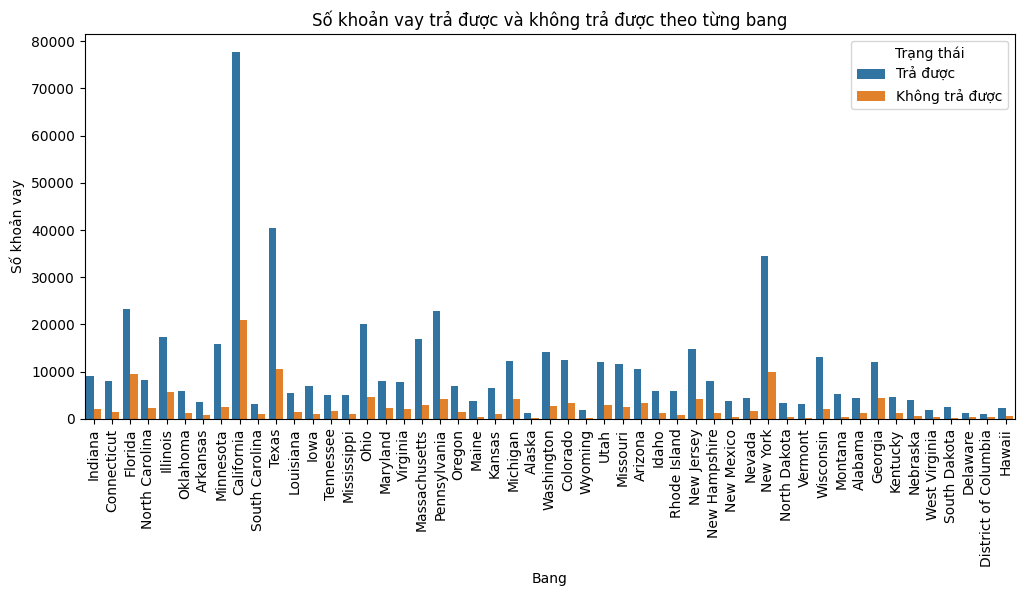

In [81]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_pandas, x='State', hue='Default')
plt.title('Số khoản vay trả được và không trả được theo từng bang')
plt.xlabel('Bang')
plt.ylabel('Số khoản vay')
plt.xticks(rotation=90)  
plt.legend(["Trả được", "Không trả được"], title="Trạng thái")

In [32]:
state_counts = (
    df.groupby('State').agg(count("*").alias('TotalLoans'),
                           sum(when(col('Default') == 1, 1).otherwise(0)).alias('DefaultedLoans'))
)


In [33]:
state_counts = state_counts.withColumn('DefaultRate', col('DefaultedLoans') / col('TotalLoans'))

In [36]:
min_val, max_val = state_counts.agg({"DefaultRate": "min"}).collect()[0][0], state_counts.agg({"DefaultRate": "max"}).collect()[0][0]

step = (max_val - min_val) / 5
state_counts = state_counts.withColumn(
    'RiskByState', 
    when(col("DefaultRate") <= min_val + step, 1)
    .when(col("DefaultRate") <= min_val + 2 * step, 2)
    .when(col("DefaultRate") <= min_val + 3 * step, 3)
    .when(col("DefaultRate") <= min_val + 4 * step, 4)
    .otherwise(5)
)

state_risk = state_counts.select('State', 'RiskByState')

In [41]:
df = df.join(state_risk, df.State == state_risk.State)
df = df.drop(state_counts.State)

In [34]:
top_10_states = state_counts.sort('DefaultRate', ascending=False).limit(10)
top_10_states.show()

+--------------------+----------+--------------+-------------------+
|               State|TotalLoans|DefaultedLoans|        DefaultRate|
+--------------------+----------+--------------+-------------------+
|             Florida|     32733|          9504| 0.2903491888919439|
|              Nevada|      6064|          1634| 0.2694591029023747|
|             Georgia|     16438|          4425| 0.2691933325222046|
|District of Columbia|      1299|           349| 0.2686682063125481|
|            Michigan|     16315|          4154| 0.2546123199509654|
|            Illinois|     23048|          5746|0.24930579659840332|
|           Tennessee|      6757|          1646| 0.2435992304277046|
|             Arizona|     13762|          3232|0.23484958581601512|
|      South Carolina|      4053|           908|0.22403158154453492|
|      North Carolina|     10495|          2345| 0.2234397332062887|
+--------------------+----------+--------------+-------------------+



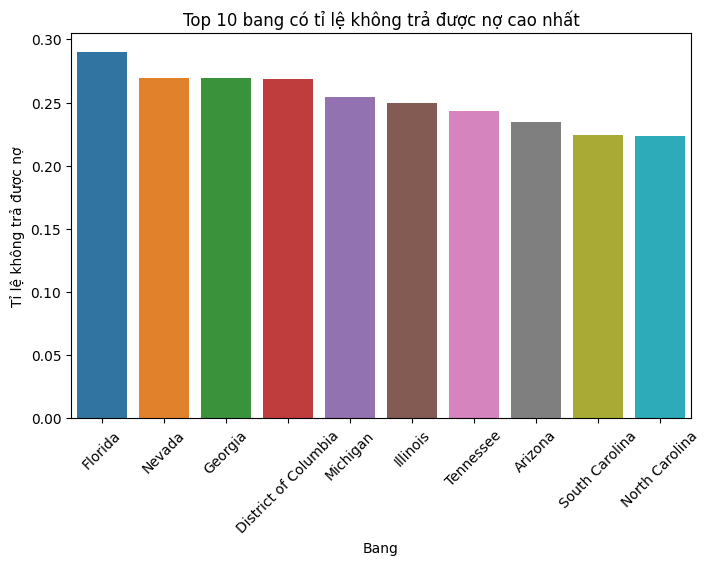

In [179]:
top_10_states_pandas = top_10_states.toPandas()
plt.figure(figsize=(8, 5))
sns.barplot(data=top_10_states_pandas, x='State', y='DefaultRate')

plt.title('Top 10 bang có tỉ lệ không trả được nợ cao nhất')
plt.xlabel('Bang')
plt.ylabel('Tỉ lệ không trả được nợ')
plt.xticks(rotation=45)
plt.show()

In [195]:
industry_df_pandas = df.select('Industry', 'Default').toPandas()

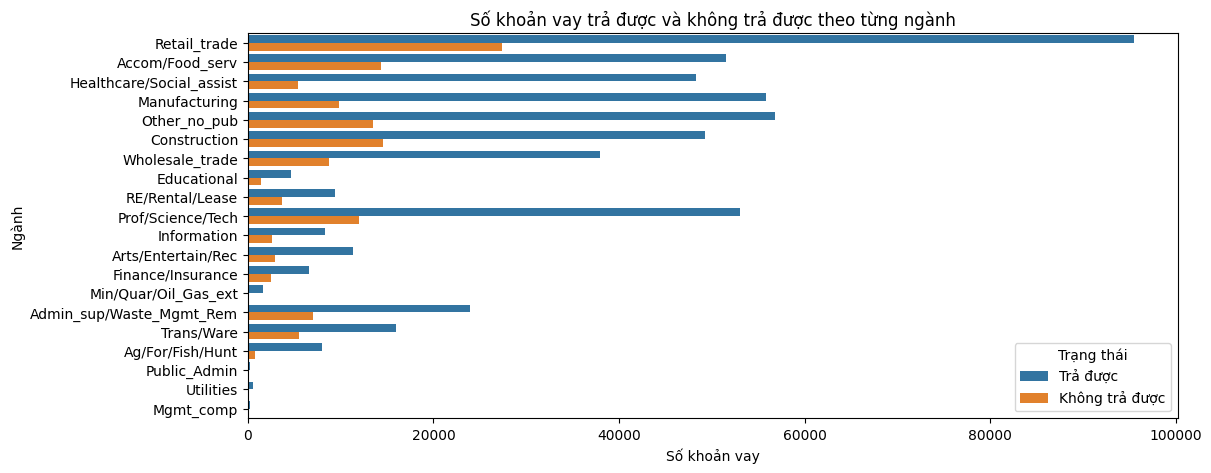

In [197]:
plt.figure(figsize=(12, 5))
sns.countplot(data=industry_df_pandas, y='Industry', hue='Default')
plt.title('Số khoản vay trả được và không trả được theo từng ngành')
plt.ylabel('Ngành')
plt.xlabel('Số khoản vay')
plt.legend(["Trả được", "Không trả được"], title="Trạng thái")

In [86]:
industry_counts = (
    df.groupby('Industry')
    .agg(
        count("*").alias('TotalLoans'),
        sum(when(col('Default') == 1, 1).otherwise(0)).alias('DefaultedLoans')
    )
)

In [87]:
industry_counts = industry_counts.withColumn('DefaultRate', col('DefaultedLoans') / col('TotalLoans'))
industry_counts.show()

+--------------------+----------+--------------+-------------------+
|            Industry|TotalLoans|DefaultedLoans|        DefaultRate|
+--------------------+----------+--------------+-------------------+
|Admin_sup/Waste_M...|     30957|          6972|0.22521562166876635|
|Healthcare/Social...|     53732|          5444|0.10131765056204868|
|  Arts/Entertain/Rec|     14168|          2874|0.20285149632975719|
|         Information|     10924|          2649|0.24249359209080923|
|     Accom/Food_serv|     65878|         14319|0.21735632532863777|
|          Trans/Ware|     21492|          5544|0.25795644891122277|
|   Finance/Insurance|      9087|          2517| 0.2769891053152856|
|         Educational|      6133|          1451| 0.2365889450513615|
|        Construction|     63736|         14513|0.22770490774444585|
|           Utilities|       642|            88|0.13707165109034267|
|     Wholesale_trade|     46764|          8761| 0.1873449662133265|
|           Mgmt_comp|       255| 

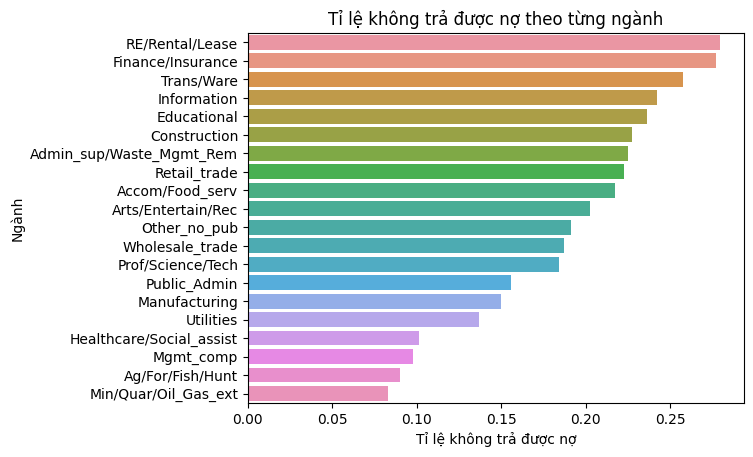

In [88]:
industry_counts_pandas = industry_counts.sort('DefaultRate', ascending=False).toPandas()
sns.barplot(data=industry_counts_pandas, y='Industry', x='DefaultRate')

plt.title('Tỉ lệ không trả được nợ theo từng ngành')
plt.ylabel('Ngành')
plt.xlabel('Tỉ lệ không trả được nợ')
plt.show()

In [202]:
def loan_count(df, group_by_column):
    loan_counts = (
        df.groupBy(group_by_column)
        .agg(
            count("*").alias("TotalLoans"),
            sum(when(col("Default") == 0, 1).otherwise(0)).alias("PaidLoans")
        )
    )
    loan_counts = loan_counts.withColumn("DefaultedLoans", col("TotalLoans") - col("PaidLoans"))
    return loan_counts

In [118]:
business_counts = loan_count(df, "NewBusiness")
business_counts_pandas = business_counts.toPandas()

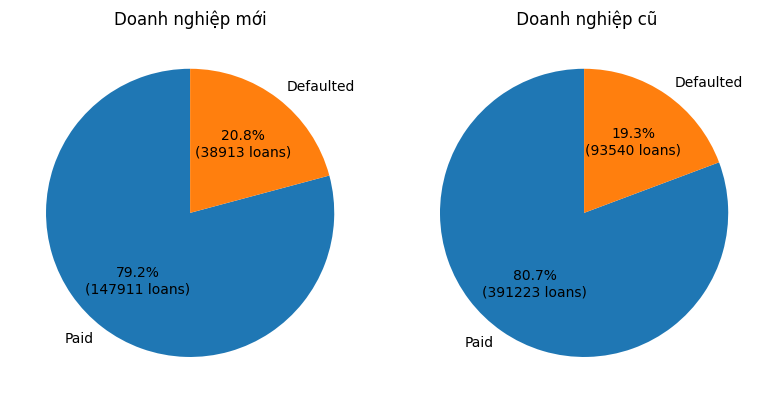

In [123]:
import numpy as np

new_business_data = business_counts_pandas[business_counts_pandas["NewBusiness"] == 1][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  # Dữ liệu cho NewBusiness = "New"
existing_business_data = business_counts_pandas[business_counts_pandas["NewBusiness"] == 0][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  # Dữ liệu cho NewBusiness = "Existing"


fig, axes = plt.subplots(1, 2, figsize=(8, 4))


def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute} loans)"
    
axes[0].pie(
    new_business_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, new_business_data),
    startangle=90,
)
axes[0].set_title("Doanh nghiệp mới")

# Biểu đồ tròn cho NewBusiness = "Existing"
axes[1].pie(
    existing_business_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, existing_business_data),
    startangle=90,
)
axes[1].set_title(" Doanh nghiệp cũ")

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [120]:
real_estate_counts = loan_count(df, "RealEstate")
real_estate_counts_pandas = real_estate_counts.toPandas()

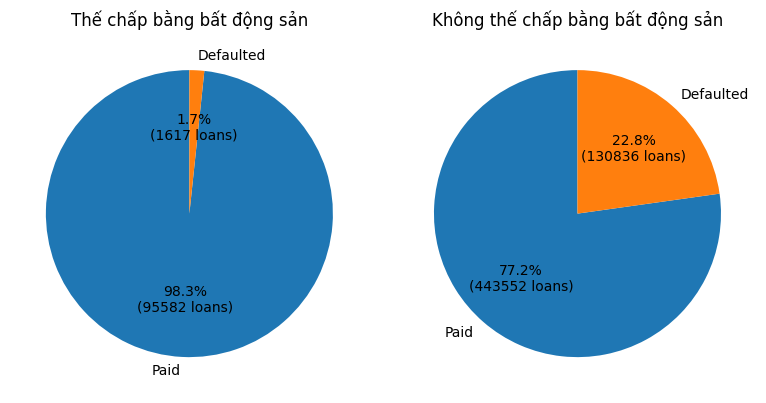

In [122]:
real_estate_data = real_estate_counts_pandas[real_estate_counts_pandas["RealEstate"] == 1][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  
not_real_estate_data = real_estate_counts_pandas[real_estate_counts_pandas["RealEstate"] == 0][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].pie(
    real_estate_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, real_estate_data),
    startangle=90,
)
axes[0].set_title("Thế chấp bằng bất động sản")

# Biểu đồ tròn cho NewBusiness = "Existing"
axes[1].pie(
    not_real_estate_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, not_real_estate_data),
    startangle=90,
)
axes[1].set_title("Không thế chấp bằng bất động sản")

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [94]:
df.select('DisbursementGross', 'Default').show()

+-----------------+-------+
|DisbursementGross|Default|
+-----------------+-------+
|          60000.0|      0|
|          40000.0|      0|
|         287000.0|      0|
|         517000.0|      0|
|          45000.0|      0|
|         305000.0|      0|
|          70000.0|      0|
|         150000.0|      0|
|         253400.0|      0|
|         350000.0|      0|
|          70000.0|      0|
|         137300.0|      0|
|          39500.0|      0|
|         438541.0|      0|
|         291000.0|      0|
|          51440.0|      0|
|         600000.0|      0|
|          50000.0|      0|
|          30000.0|      0|
|          63076.0|      0|
+-----------------+-------+
only showing top 20 rows



In [95]:
df.columns

['State',
 'Term',
 'NoEmp',
 'CreateJob',
 'RetainedJob',
 'UrbanRural',
 'RevLineCr',
 'LowDoc',
 'DisbursementDate',
 'DisbursementGross',
 'NewBusiness',
 'IsFranchised',
 'Default',
 'Industry',
 'Recession',
 'RealEstate',
 'Portion']

In [96]:
from pyspark.sql.functions import max as smax
import numpy as np

In [111]:
def get_quartiles(df, column, group_by_col):
    quartiles = [0.25, 0.50, 0.75]  
    summary = []
    
    for value in df.select(group_by_col).distinct().rdd.flatMap(lambda x: x).collect():
        filtered_df = df.filter(col(group_by_col) == value)
        quantiles = filtered_df.approxQuantile(column, quartiles, 0)
        min_val = filtered_df.select(smin(column)).collect()[0][0]
        max_val = filtered_df.select(smax(column)).collect()[0][0]
        summary.append([value, min_val, *quantiles, max_val])
    
    return summary


summary = get_quartiles(df, "DisbursementGross", "Default")

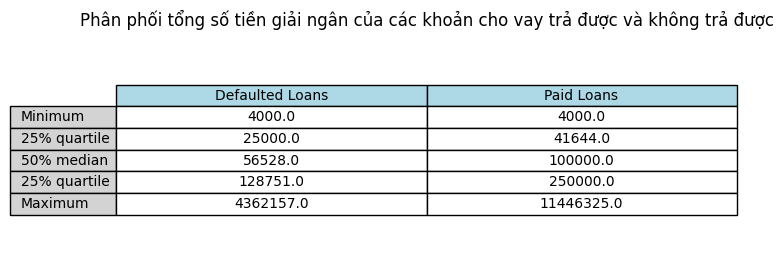

In [113]:
quartiles_of_gross_disbursement = np.array(summary).T
default_mapping = {
    1: 'Defaulted Loans',
    0: 'Paid Loans'
}
columns = [default_mapping[x] for x in quartiles_of_gross_disbursement[0]]
rows = ['Minimum', '25% quartile', '50% median', '25% quartile', 'Maximum']
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("tight")
ax.axis("off")

# Thêm bảng vào figure
table = ax.table(cellText=quartiles_of_gross_disbursement[1:], colLabels=columns, rowLabels=rows, cellLoc="center", loc="center", rowColours=["lightgray"]*5, colColours=['lightblue']*2)
plt.title("Phân phối tổng số tiền giải ngân của các khoản cho vay trả được và không trả được")
table.scale(1, 1.3)

In [181]:
recession_counts = loan_count(df, "Recession")
recession_counts_pandas = recession_counts.toPandas()

In [183]:
recession_counts_pandas

,Recession,TotalLoans,PaidLoans,DefaultedLoans
0,1,59848,39195,20653
1,0,611739,499939,111800


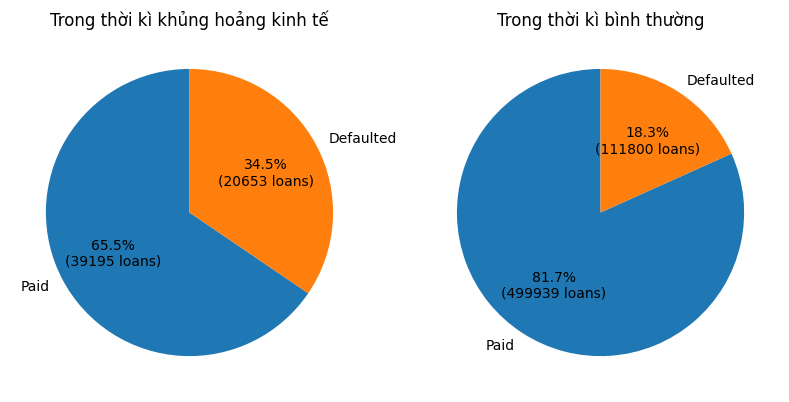

In [186]:
recession_data = recession_counts_pandas[recession_counts_pandas["Recession"] == 1][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  
not_recession_data = recession_counts_pandas[recession_counts_pandas["Recession"] == 0][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].pie(
    recession_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, recession_data),
    startangle=90,
)
axes[0].set_title("Trong thời kì khủng hoảng kinh tế")

# Biểu đồ tròn cho NewBusiness = "Existing"
axes[1].pie(
    not_recession_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, not_recession_data),
    startangle=90,
)
axes[1].set_title("Trong thời kì bình thường")

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [44]:
df.columns

['Term',
 'NoEmp',
 'CreateJob',
 'RetainedJob',
 'UrbanRural',
 'RevLineCr',
 'LowDoc',
 'DisbursementGross',
 'NewBusiness',
 'IsFranchised',
 'Default',
 'Industry',
 'Recession',
 'RealEstate',
 'Portion',
 'State',
 'RiskByState']

In [189]:
portion_df = df.select('Portion', 'Default').toPandas()

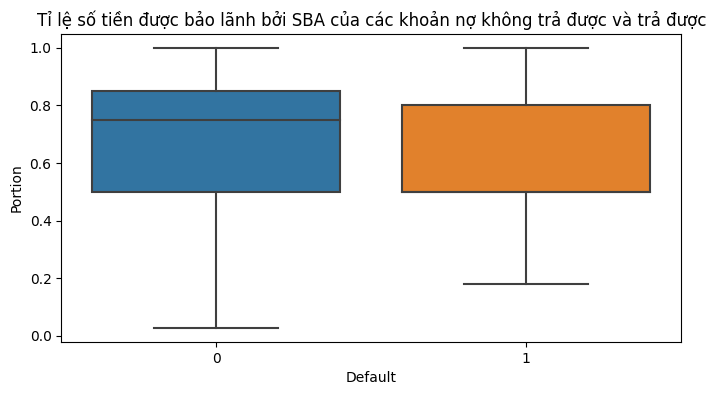

In [207]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=portion_df, x='Default', y='Portion')
plt.title("Tỉ lệ số tiền được bảo lãnh bởi SBA của các khoản nợ không trả được và trả được")
plt.show()

In [203]:
revlinecr_counts = loan_count(df, "RevLineCr")
revlinecr_counts_pandas = revlinecr_counts.toPandas()

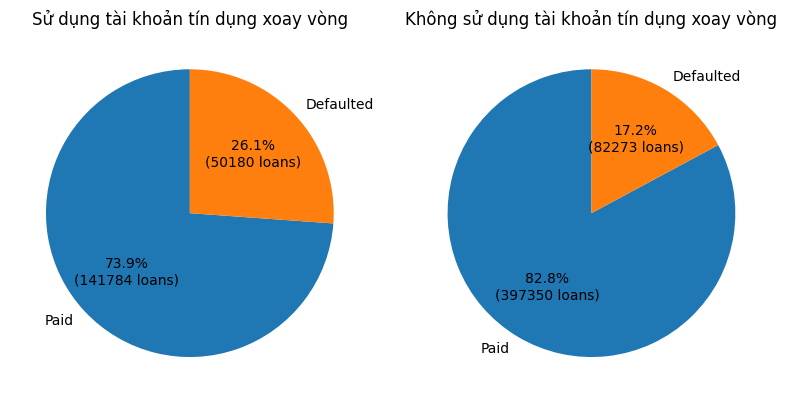

In [205]:
revlinecr_data = revlinecr_counts_pandas[revlinecr_counts_pandas["RevLineCr"] == 1][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  
not_revlinecr_data = revlinecr_counts_pandas[revlinecr_counts_pandas["RevLineCr"] == 0][['PaidLoans', 'DefaultedLoans']].iloc[0].tolist()  

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].pie(
    revlinecr_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, revlinecr_data),
    startangle=90,
)
axes[0].set_title("Sử dụng tài khoản tín dụng xoay vòng")

# Biểu đồ tròn cho NewBusiness = "Existing"
axes[1].pie(
    not_revlinecr_data,
    labels=["Paid", "Defaulted"],
    autopct=lambda pct: func(pct, not_revlinecr_data),
    startangle=90,
)
axes[1].set_title("Không sử dụng tài khoản tín dụng xoay vòng")

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [210]:
df.columns

['State',
 'Term',
 'NoEmp',
 'CreateJob',
 'RetainedJob',
 'UrbanRural',
 'RevLineCr',
 'LowDoc',
 'DisbursementGross',
 'NewBusiness',
 'IsFranchised',
 'Default',
 'Industry',
 'Recession',
 'RealEstate',
 'Portion']

In [42]:
df.printSchema()

root
 |-- State: string (nullable = true)
 |-- Term: integer (nullable = true)
 |-- NoEmp: integer (nullable = true)
 |-- CreateJob: integer (nullable = true)
 |-- RetainedJob: integer (nullable = true)
 |-- UrbanRural: integer (nullable = true)
 |-- RevLineCr: integer (nullable = true)
 |-- LowDoc: integer (nullable = true)
 |-- DisbursementGross: float (nullable = true)
 |-- NewBusiness: integer (nullable = false)
 |-- IsFranchised: integer (nullable = false)
 |-- Default: integer (nullable = false)
 |-- Industry: string (nullable = true)
 |-- Recession: integer (nullable = false)
 |-- RealEstate: integer (nullable = false)
 |-- Portion: double (nullable = true)
 |-- State: string (nullable = true)
 |-- RiskByState: integer (nullable = false)



In [45]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, MinMaxScaler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

categorical_cols = ["RiskByState", "Industry"]
numerical_cols = ["Term", "NoEmp", "CreateJob", "RetainedJob", "DisbursementGross", "Portion"]
other_cols = ["UrbanRural", "RevLineCr", "LowDoc", "NewBusiness", "IsFranchised", "Recession", "RealEstate"]

indexers = [StringIndexer(inputCol=col, outputCol=col + "Indexed", handleInvalid="keep") for col in categorical_cols]

numerical_assembler = VectorAssembler(inputCols=numerical_cols, outputCol="numerical_features")

scaler = MinMaxScaler(inputCol="numerical_features", outputCol="scaled_numerical_features")


feature_cols = ["scaled_numerical_features"] + [col + "Indexed" for col in categorical_cols] + other_cols
final_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

pipeline = Pipeline(stages=indexers + [numerical_assembler, scaler, final_assembler])

# Áp dụng pipeline lên dữ liệu
df_transformed = pipeline.fit(df).transform(df)

# Chọn cột cần thiết
df_transformed = df_transformed.select("features", "Default")

In [46]:
fractions = {0: 0.8, 1: 0.8} 

train_data = df_transformed.stat.sampleBy("Default", fractions, seed=42)
test_data = df_transformed.subtract(train_data)

In [47]:
def calculate_metrics(predictions, labelCol):
    tp = predictions.filter((col("prediction") == 1) & (col("Default") == 1)).count()  # True Positive
    tn = predictions.filter((col("prediction") == 0) & (col("Default") == 0)).count()  # True Negative
    fp = predictions.filter((col("prediction") == 1) & (col("Default") == 0)).count()  # False Positive
    fn = predictions.filter((col("prediction") == 0) & (col("Default") == 1)).count()  # False Negative

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0  # Tránh chia cho 0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Tránh chia cho 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                            
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1_score:.4f}")

In [48]:
dt = DecisionTreeClassifier(labelCol="Default", featuresCol="features", maxBins=100)
dt_model = dt.fit(train_data)
dt_predictions = dt_model.transform(test_data)
calculate_metrics(dt_predictions, "Default")

Accuracy: 0.8821
Precision: 0.7067
Recall: 0.7507
F1-score: 0.7280


In [47]:
rf = RandomForestClassifier(labelCol="Default", featuresCol="features")
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
calculate_metrics(rf_predictions, "Default")

Accuracy: 0.8496
Precision: 0.6876
Recall: 0.5538
F1-score: 0.6135
